### Imports

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import functional as TF
from PIL import Image
from sklearn.model_selection import train_test_split
import kagglehub
import glob
from torchvision.models import vgg16, VGG16_Weights
import torchvision.transforms.functional as TF
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Data Preprocessing

In [ ]:
path = kagglehub.dataset_download("felicepollano/watermarked-not-watermarked-images")

print("Path to dataset files:", path)

base_path = "/kaggle/input/watermarked-not-watermarked-images/wm-nowm"
train_watermarked = os.path.join(base_path, "train", "watermark")
train_no_watermark = os.path.join(base_path, "train", "no-watermark")
valid_dir = os.path.join(base_path, "valid")

print("Dataset folders:")
print("Watermarked train samples:", len(os.listdir(train_watermarked)))
print("No-watermark train samples:", len(os.listdir(train_no_watermark)))
print("Validation folder exists:", os.path.exists(valid_dir))

Using Colab cache for faster access to the 'watermarked-not-watermarked-images' dataset.
Path to dataset files: /kaggle/input/watermarked-not-watermarked-images
Dataset folders:
Watermarked train samples: 12510
No-watermark train samples: 12477
Validation folder exists: True


In [ ]:
base_path = os.path.join(path, "wm-nowm")

no_watermark_path = os.path.join(base_path, "train", "no-watermark")
watermark_path    = os.path.join(base_path, "train", "watermark")

print("No-watermark path:", no_watermark_path)
print("Watermark path:", watermark_path)

print("\nFinding matching image pairs...")
all_wm_images = glob.glob(os.path.join(watermark_path, "*.*"))
all_no_wm_images = glob.glob(os.path.join(no_watermark_path, "*.*"))

wm_filenames = {os.path.basename(p): p for p in all_wm_images}
no_wm_filenames = {os.path.basename(p): p for p in all_no_wm_images}

matching_names = set(wm_filenames.keys()) & set(no_wm_filenames.keys())

matching_pairs = [
    {
        "filename": name,
        "watermark": wm_filenames[name],
        "no_watermark": no_wm_filenames[name]
    }
    for name in sorted(matching_names)
]

print("\n========================================")
print("MATCHING PAIRS SUMMARY")
print("========================================")
print(f"Total watermarked images:   {len(all_wm_images)}")
print(f"Total no-watermark images:  {len(all_no_wm_images)}")
print(f"Matching pairs found:       {len(matching_pairs)}")
print("========================================\n")

with open("matching_pairs.txt", "w") as f:
    f.write(f"Total matching pairs: {len(matching_pairs)}\n\n")
    for pair in matching_pairs:
        f.write(f"{pair['filename']}\n")
        f.write(f"  WM:  {pair['watermark']}\n")
        f.write(f"  NOWM:{pair['no_watermark']}\n\n")

print("✓ matching_pairs is now ready to use in the rest of the notebook!")


Downloaded to: /root/.cache/kagglehub/datasets/felicepollano/watermarked-not-watermarked-images/versions/1
No-watermark path: /root/.cache/kagglehub/datasets/felicepollano/watermarked-not-watermarked-images/versions/1/wm-nowm/train/no-watermark
Watermark path: /root/.cache/kagglehub/datasets/felicepollano/watermarked-not-watermarked-images/versions/1/wm-nowm/train/watermark

Finding matching image pairs...

MATCHING PAIRS SUMMARY
Total watermarked images:   12510
Total no-watermark images:  12477
Matching pairs found:       1743

✓ matching_pairs is now ready to use in the rest of the notebook!


In [ ]:
watermarked_imgs = sorted(glob.glob(os.path.join(train_watermarked, "*.jpg")) +
                          glob.glob(os.path.join(train_watermarked, "*.png")))
clean_imgs = sorted(glob.glob(os.path.join(train_no_watermark, "*.jpg")) +
                    glob.glob(os.path.join(train_no_watermark, "*.png")))

print(f"Found watermarked: {len(watermarked_imgs)}")
print(f"Found clean: {len(clean_imgs)}")

# Create matching pairs
matching_pairs = []
for wm_path, clean_path in zip(watermarked_imgs, clean_imgs):
    matching_pairs.append({
        'watermark': wm_path,
        'no_watermark': clean_path,
        'filename': os.path.basename(wm_path)
    })

print(f"Total matching pairs: {len(matching_pairs)}")

# Split into train/validation
train_pairs, val_pairs = train_test_split(matching_pairs, test_size=0.15, random_state=42)
print(f"Train: {len(train_pairs)} pairs")
print(f"Validation: {len(val_pairs)} pairs")


Found watermarked: 186
Found clean: 183
Total matching pairs: 183
Train: 155 pairs
Validation: 28 pairs


### Create classes, models,

In [ ]:
class WatermarkDataset(Dataset):
    def __init__(self, pairs, img_size=256, augment=False):
        self.pairs = pairs
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]

        watermark_img = Image.open(pair['watermark']).convert('RGB')
        clean_img = Image.open(pair['no_watermark']).convert('RGB')

        watermark_img = watermark_img.resize((self.img_size, self.img_size))
        clean_img = clean_img.resize((self.img_size, self.img_size))

        # mask from difference
        watermark_np = np.array(watermark_img).astype(float)
        clean_np = np.array(clean_img).astype(float)
        diff = np.abs(watermark_np - clean_np)
        mask = (diff.mean(axis=2) > 15).astype(np.float32)

        if self.augment and np.random.rand() > 0.5:
            if np.random.rand() > 0.5:
                watermark_img = TF.hflip(watermark_img)
                clean_img = TF.hflip(clean_img)
                mask = np.fliplr(mask).copy()

            if np.random.rand() > 0.5:
                jitter = transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
                watermark_img = jitter(watermark_img)
                clean_img = jitter(clean_img)

        # convert to tensors
        watermark_tensor = TF.to_tensor(watermark_img)
        clean_tensor = TF.to_tensor(clean_img)
        mask_tensor = torch.from_numpy(mask).unsqueeze(0)

        return watermark_tensor, clean_tensor, mask_tensor

### Model Architecture

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.pool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.pool_conv(x)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, 2, 2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class WatermarkRemovalUNet(nn.Module):
    """
    U-Net that takes watermarked image and outputs clean image directly.
    No mask prediction - just image-to-image translation.
    """
    def __init__(self):
        super().__init__()
        # encoder
        self.inc = DoubleConv(3, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024)

        # decoder
        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)

        self.outc = nn.Conv2d(64, 3, 1)

    def forward(self, x):
        # encoder with skip connections
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        # decoder
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        clean = self.outc(x)

        return clean

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

class PatchGANDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # takes both input and ground truth images
        self.model = nn.Sequential(
            nn.Conv2d(6, 64, 4, stride=2, padding=1),  # 6 = 3 (input) + 3 (output)
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, 4, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
            nn.Conv2d(512, 1, 4, stride=1, padding=1),
        )

    def forward(self, input_img, output_img):
        x = torch.cat([input_img, output_img], dim=1)
        return self.model(x)

# setup
generator = WatermarkRemovalUNet().to(device)
discriminator = PatchGANDiscriminator().to(device)

g_optimizer = torch.optim.Adam(generator.parameters(), lr=2e-4)
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=2e-4)

adversarial_loss = nn.BCEWithLogitsLoss()

Using device: cpu


### Training Setup

In [ ]:
# globals

IMG_SIZE = 256
BATCH_SIZE = 8
LEARNING_RATE = 2e-4
NUM_EPOCHS = 10
LAMBDA_L1 = 100

train_dataset = WatermarkDataset(train_pairs, img_size=IMG_SIZE, augment=True)
val_dataset = WatermarkDataset(val_pairs, img_size=IMG_SIZE, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

generator = WatermarkRemovalUNet().to(device)
discriminator = PatchGANDiscriminator().to(device)

g_optimizer = torch.optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))

g_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(g_optimizer, mode='min', factor=0.5, patience=5)
d_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(d_optimizer, mode='min', factor=0.5, patience=5)

adversarial_loss = nn.BCEWithLogitsLoss()
l1_loss = nn.L1Loss()


Using device: cpu


### Training Loop


Epoch 1/10
----------------------------------------------------------------------


Training: 100%|██████████| 20/20 [23:36<00:00, 70.82s/it]
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Generator Loss: 40.9707
Discriminator Loss: 0.6073
Validation L1 Loss: 0.3272
✓ Saved best model!

Epoch 2/10
----------------------------------------------------------------------


Training: 100%|██████████| 20/20 [23:44<00:00, 71.21s/it]
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Generator Loss: 28.6486
Discriminator Loss: 0.6235
Validation L1 Loss: 0.2817
✓ Saved best model!

Epoch 3/10
----------------------------------------------------------------------


...

Generator Loss: 28.6013
Discriminator Loss: 0.3589
Validation L1 Loss: 0.2977

Epoch 9/10
----------------------------------------------------------------------


Training: 100%|██████████| 20/20 [23:38<00:00, 70.91s/it]
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Generator Loss: 28.5327
Discriminator Loss: 0.3403
Validation L1 Loss: 0.2658

Epoch 10/10
----------------------------------------------------------------------


Training: 100%|██████████| 20/20 [23:34<00:00, 70.72s/it]
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Generator Loss: 28.4339
Discriminator Loss: 0.3351
Validation L1 Loss: 0.2623
✓ Saved best model!


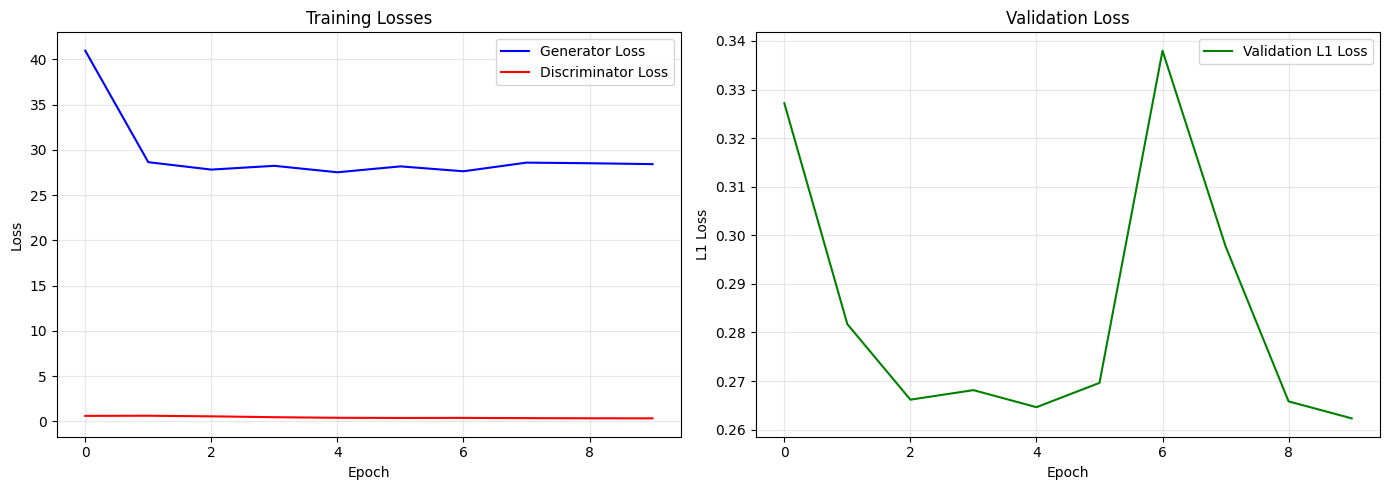

In [ ]:
# training for each epoch
def train_epoch(generator, discriminator, train_loader, g_optimizer, d_optimizer, device):
    generator.train()
    discriminator.train()

    g_losses = []
    d_losses = []

    for watermark_img, clean_img, _ in tqdm(train_loader, desc="Training"):
        watermark_img = watermark_img.to(device)
        clean_img = clean_img.to(device)
        batch_size = watermark_img.size(0)

        d_optimizer.zero_grad()

        real_pred = discriminator(watermark_img, clean_img)
        real_label = torch.ones_like(real_pred) * 0.9
        d_loss_real = adversarial_loss(real_pred, real_label)

        fake_clean = generator(watermark_img)
        fake_pred = discriminator(watermark_img, fake_clean.detach())
        fake_label = torch.zeros_like(fake_pred) + 0.1
        d_loss_fake = adversarial_loss(fake_pred, fake_label)

        # discriminator loss
        d_loss = (d_loss_real + d_loss_fake) / 2
        d_loss.backward()
        d_optimizer.step()


        g_optimizer.zero_grad()
        fake_clean = generator(watermark_img)
        fake_pred = discriminator(watermark_img, fake_clean)

        g_adversarial_loss = adversarial_loss(fake_pred, torch.ones_like(fake_pred))

        g_l1_loss = l1_loss(fake_clean, clean_img)

        g_loss = g_adversarial_loss + LAMBDA_L1 * g_l1_loss
        g_loss.backward()
        g_optimizer.step()

        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())

    return np.mean(g_losses), np.mean(d_losses)


def validate(generator, val_loader, device):
    generator.eval()
    val_losses = []

    with torch.no_grad():
        for watermark_img, clean_img, _ in val_loader:
            watermark_img = watermark_img.to(device)
            clean_img = clean_img.to(device)

            fake_clean = generator(watermark_img)
            loss = l1_loss(fake_clean, clean_img)
            val_losses.append(loss.item())

    return np.mean(val_losses)


best_val_loss = float('inf')
history = {
    'g_loss': [],
    'd_loss': [],
    'val_loss': []
}

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 70)

    # train
    g_loss, d_loss = train_epoch(generator, discriminator, train_loader,
                                   g_optimizer, d_optimizer, device)

    # validate
    val_loss = validate(generator, val_loader, device)

    # record history
    history['g_loss'].append(g_loss)
    history['d_loss'].append(d_loss)
    history['val_loss'].append(val_loss)

    print(f"Generator Loss: {g_loss:.4f}")
    print(f"Discriminator Loss: {d_loss:.4f}")
    print(f"Validation L1 Loss: {val_loss:.4f}")

    # save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'generator_state_dict': generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
            'g_optimizer_state_dict': g_optimizer.state_dict(),
            'd_optimizer_state_dict': d_optimizer.state_dict(),
            'val_loss': val_loss,
        }, 'best_pix2pix_model.pth')
        print("✓ Saved best model!")

    g_scheduler.step(val_loss)
    d_scheduler.step(d_loss)

    if (epoch + 1) % 10 == 0:
        torch.save({
            'epoch': epoch,
            'generator_state_dict': generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
        }, f'pix2pix_checkpoint_epoch_{epoch+1}.pth')

# plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['g_loss'], label='Generator Loss', color='blue')
axes[0].plot(history['d_loss'], label='Discriminator Loss', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Losses')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['val_loss'], label='Validation L1 Loss', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('L1 Loss')
axes[1].set_title('Validation Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pix2pix_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualization and Inference


Loading best model for inference...
Loaded model from epoch 4 with val loss 0.2646
Processing 1/8: black-and-white-city-houses-skyline.jpg
Processing 2/8: glass-rainy-car-rain.jpg
Processing 3/8: pexels-photo-9808.jpg
Processing 4/8: pexels-photo-3050287.png
Processing 5/8: pexels-photo-4562477.png
Processing 6/8: bird-animal-beak-feathers.jpg
Processing 7/8: car-refill-transportation-transport.jpg
Processing 8/8: man-relax-couch-study.jpg


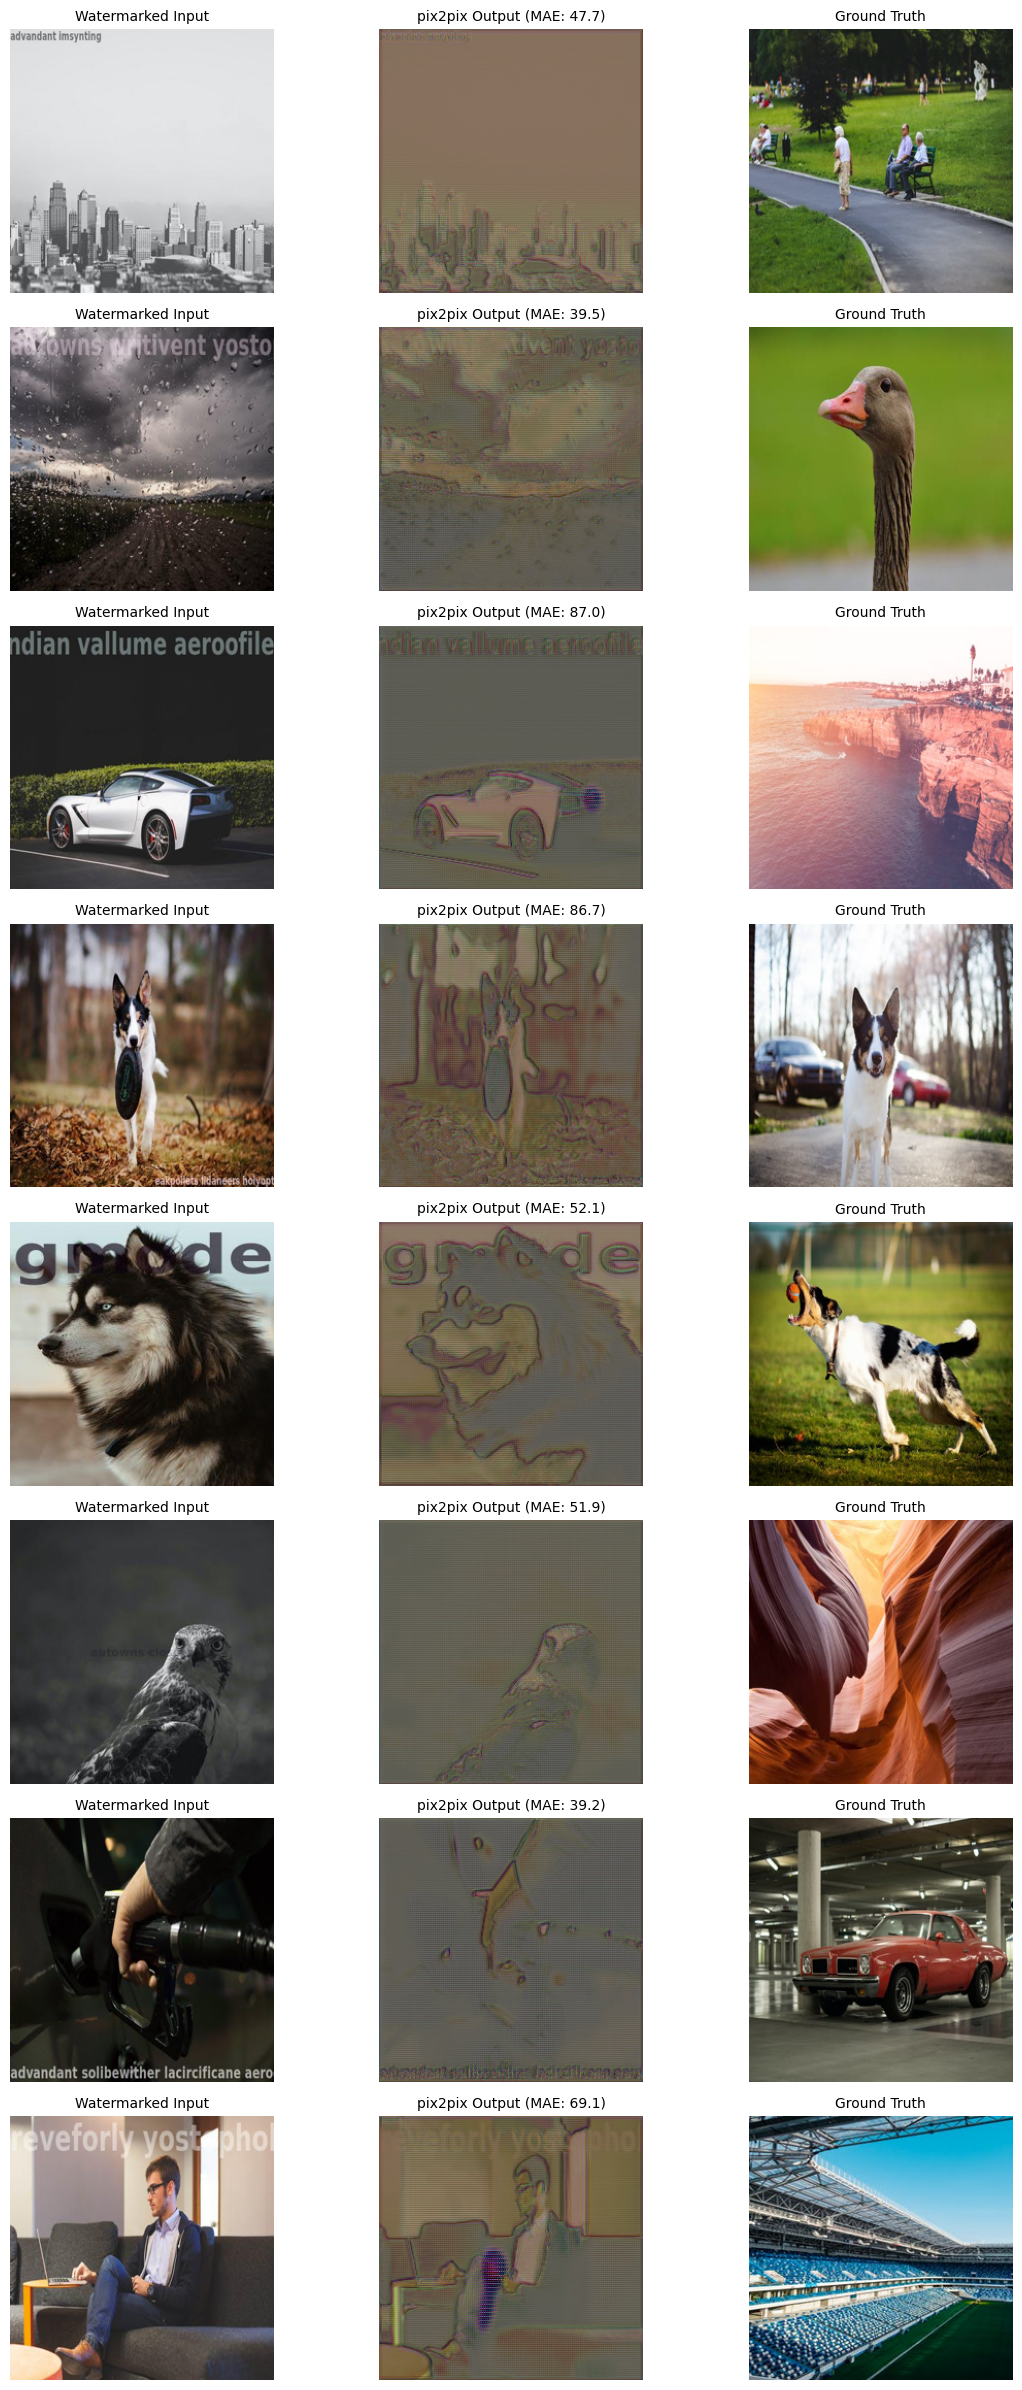


MASK DETECTION METRICS (pix2pix)


Computing mask metrics:  36%|███▌      | 10/28 [00:18<00:32,  1.79s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Computing mask metrics: 100%|██████████| 28/28 [00:49<00:00,  1.76s/it]


WATERMARK REMOVAL QUALITY METRICS
Precision:  0.8946 ± 0.2532
Recall:     0.0186 ± 0.0267
F1 Score:   0.0351 ± 0.0477
IoU:        0.0185 ± 0.0266

Interpretation: How well watermark pixels were restored to match clean GT


In [ ]:
IMG_SIZE = 256
BATCH_SIZE = 8
LEARNING_RATE = 2e-4
NUM_EPOCHS = 10
LAMBDA_L1 = 100

print("\nLoading best model for inference...")
checkpoint = torch.load('best_pix2pix_model.pth', weights_only=False)
model = torch.load('best_pix2pix_model.pth', weights_only=False)
generator.load_state_dict(checkpoint['generator_state_dict'])
generator.eval()
print(f"Loaded model from epoch {checkpoint['epoch']} with val loss {checkpoint['val_loss']:.4f}")

def remove_watermark_pix2pix(img_path, generator, device, img_size=256):
    img = Image.open(img_path).convert('RGB')
    original_size = img.size

    img_resized = img.resize((img_size, img_size))
    img_tensor = TF.to_tensor(img_resized).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_clean = generator(img_tensor)

    pred_clean = pred_clean[0].cpu().permute(1, 2, 0).numpy()
    pred_clean = np.clip(pred_clean, 0, 1)

    pred_clean_pil = Image.fromarray((pred_clean * 255).astype(np.uint8))

    return np.array(img_resized), (pred_clean * 255).astype(np.uint8)


sample_pairs = val_pairs[:8]

fig, axes = plt.subplots(8, 3, figsize=(12, 24))

for i, pair in enumerate(sample_pairs):
    print(f"Processing {i+1}/{len(sample_pairs)}: {pair['filename']}")

    watermarked, cleaned = remove_watermark_pix2pix(pair['watermark'], generator, device)
    clean_gt = Image.open(pair['no_watermark']).convert('RGB')
    clean_gt = np.array(clean_gt.resize((IMG_SIZE, IMG_SIZE)))

    # error
    error = np.abs(cleaned.astype(int) - clean_gt.astype(int)).astype(np.uint8)
    mae = np.mean(error)

    # disp
    axes[i, 0].imshow(watermarked)
    axes[i, 0].set_title('Watermarked Input', fontsize=10)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(cleaned)
    axes[i, 1].set_title(f'pix2pix Output (MAE: {mae:.1f})', fontsize=10)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(clean_gt)
    axes[i, 2].set_title('Ground Truth', fontsize=10)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig('pix2pix_results.png', dpi=150, bbox_inches='tight')
plt.show()

precision_scores = []
recall_scores = []
f1_scores = []
iou_scores = []

for pair in tqdm(val_pairs, desc="Computing mask metrics"):
    watermarked_img = Image.open(pair['watermark']).convert('RGB')
    watermarked_img = np.array(watermarked_img.resize((IMG_SIZE, IMG_SIZE)))

    clean_gt = Image.open(pair['no_watermark']).convert('RGB')
    clean_gt = np.array(clean_gt.resize((IMG_SIZE, IMG_SIZE)))

    # generate prediction
    _, cleaned = remove_watermark_pix2pix(pair['watermark'], generator, device)

    diff_gt = np.abs(watermarked_img.astype(int) - clean_gt.astype(int))
    mask_gt = (diff_gt.mean(axis=2) > 10).astype(np.uint8)

    diff_pred = np.abs(cleaned.astype(int) - clean_gt.astype(int))
    mask_pred = (diff_pred.mean(axis=2) > 10).astype(np.uint8)

    success_mask = 1 - mask_pred  # pixels that match clean GT
    watermark_mask = mask_gt      # actual watermark locations

    watermark_flat = watermark_mask.flatten()
    success_flat = success_mask.flatten()

    if watermark_flat.sum() == 0:
        continue

    precision = precision_score(watermark_flat, success_flat, zero_division=0)
    recall = recall_score(watermark_flat, success_flat, zero_division=0)
    f1 = f1_score(watermark_flat, success_flat, zero_division=0)
    iou = jaccard_score(watermark_flat, success_flat, zero_division=0)

    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)
    iou_scores.append(iou)

print(f"Precision:  {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall:     {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1 Score:   {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"IoU:        {np.mean(iou_scores):.4f} ± {np.std(iou_scores):.4f}")
print(f"\nInterpretation: How well watermark pixels were restored to match clean GT")
print("=" * 70)


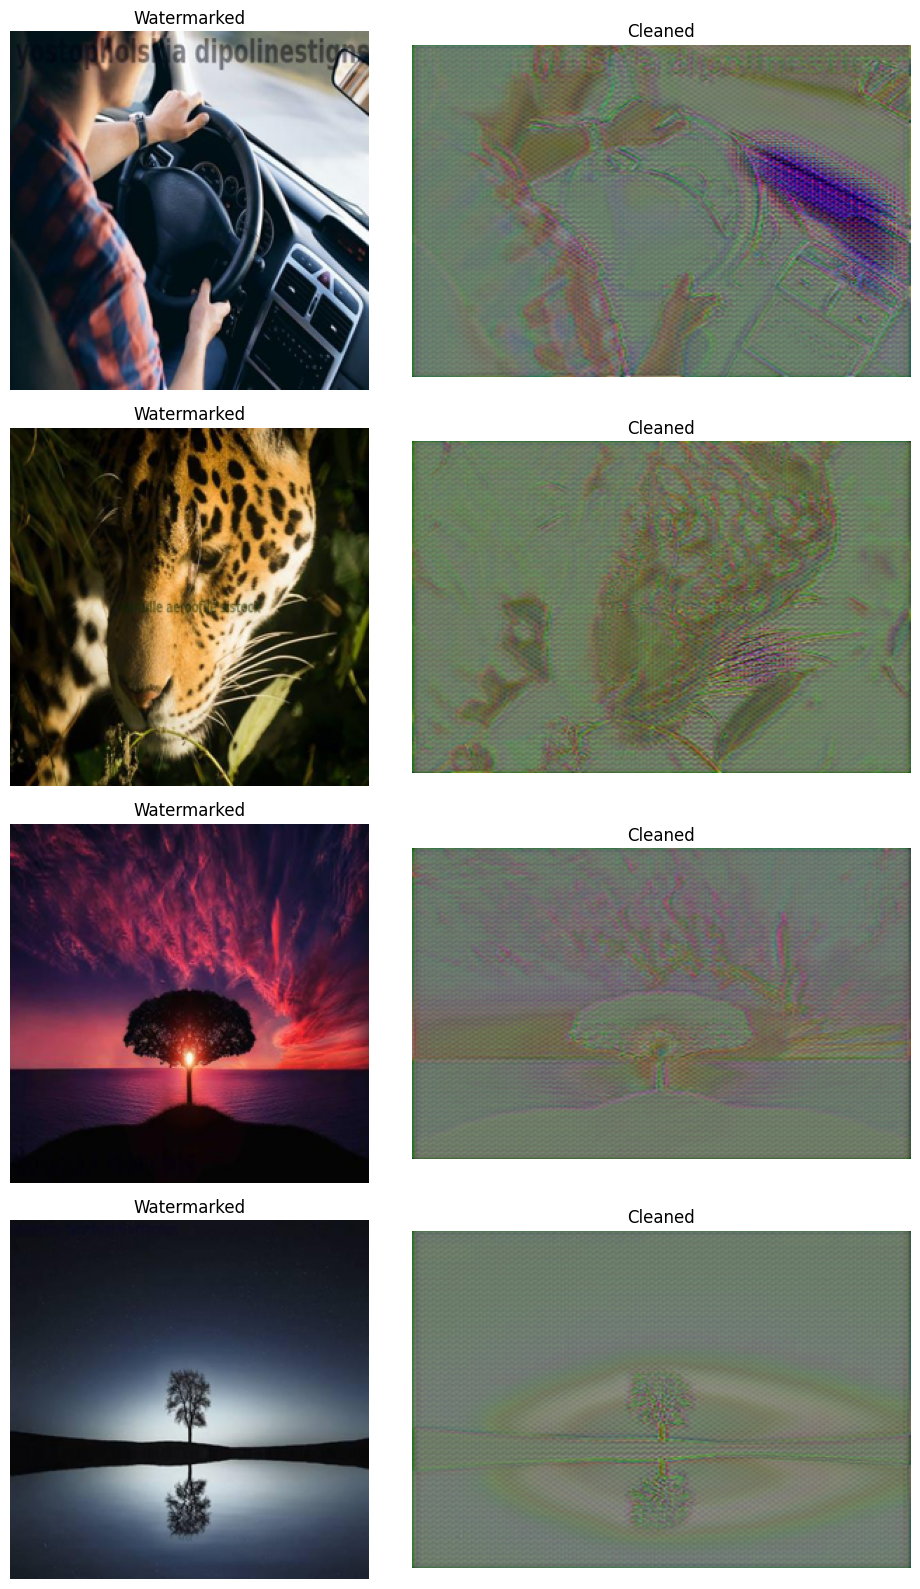

In [ ]:
model.eval()

def remove_watermark(img_path):
    img = Image.open(img_path).convert('RGB')
    original_size = img.size

    img_resized = img.resize((IMG_SIZE, IMG_SIZE))
    img_tensor = TF.to_tensor(img_resized).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_clean = model(img_tensor)

    pred_clean = pred_clean[0].cpu().permute(1, 2, 0).numpy()
    pred_clean = np.clip(pred_clean, 0, 1)

    pred_clean = cv2.resize(pred_clean, original_size)

    return np.array(img_resized), (pred_clean * 255).astype(np.uint8)

# test on samples
sample_paths = watermarked_imgs[:4]

fig, axes = plt.subplots(4, 2, figsize=(10, 16))
for i, img_path in enumerate(sample_paths):
    original, cleaned = remove_watermark(img_path)

    axes[i, 0].imshow(original)
    axes[i, 0].set_title('Watermarked')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(cleaned)
    axes[i, 1].set_title('Cleaned')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.savefig('watermark_removal_results.png', dpi=150, bbox_inches='tight')
plt.show()